In [1]:
!pip install datascope

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.8 MB/s eta 0:00:00
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.8/259.8 kB 16.7 MB/s eta 0:00:00
  Created wheel for datascope: filename=datascope-0.0.32-cp311-cp311-linux_x86_64.whl size=195808 sha256=362bac78a49e22032850c58af3873625c40d44c28d69e83b091016ab9ba8123e
  Stored in directory: /root/.cache/pip/wheels/67/c8/5a/d7857d2405cd97a220eef802f46f049d703710fd91d308728a
Successfully built datascope
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfull

In [ ]:
# This will restart the Colab runtime
import os
os.kill(os.getpid(), 9)

In [1]:
SEED=0

import copy
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load the UCI datasets.
data = fetch_openml(data_id=1590, as_frame=True)
data["frame"]
X_frame, y_frame = data["data"].copy(), data["target"].copy()

y_frame = pd.Series(LabelEncoder().fit_transform(y_frame).flatten())
X, y = X_frame.to_numpy(), y_frame.to_numpy()

# Split the dataset into train and test sets.
N_TRAIN, N_VAL, N_TEST = 10000, 2000, 2000

X_train, X_test, y_train, y_test = train_test_split(X, y,
                train_size=N_TRAIN+N_VAL, test_size=N_TEST, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                train_size=N_TRAIN, test_size=N_VAL, random_state=SEED)

In [2]:
X_train_dirty, y_train_dirty = copy.deepcopy(X_train), copy.deepcopy(y_train)
dirty_idx = np.random.RandomState(seed=SEED).choice(a=[False, True], size=(N_TRAIN), p=[0.8, 0.2])
y_train_dirty[dirty_idx] = 1 - y_train[dirty_idx]

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

imputer = SimpleImputer(strategy='most_frequent')

numeric_features = ["age", "fnlwgt", "education-num",
                    "capital-gain", "capital-loss", "hours-per-week"]
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)

categorical_features = ["workclass", "education", "marital-status", "occupation",
                    "relationship", "race", "sex", "native-country"]
categorical_transformer = OrdinalEncoder(handle_unknown="use_encoded_value",
                                         unknown_value=-1)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,
         [X_frame.columns.get_loc(x) for x in numeric_features]),
        ("cat", categorical_transformer,
         [X_frame.columns.get_loc(x) for x in categorical_features]),
    ]
)

model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
                        max_depth=8, random_state=SEED)

pipeline = Pipeline([
    ("missing_val_impute", imputer ),
    ("preprocessor", preprocessor),
    ("model", model),
])

pipeline.fit(X_train_dirty, y_train_dirty)
y_pred = pipeline.predict(X_test)
accuracy_dirty = accuracy_score(y_test, y_pred)
print("Pipeline accuracy in the beginning:", accuracy_dirty)

Pipeline accuracy in the beginning: 0.7395


In [4]:
from datascope.importance import SklearnModelEqualizedOddsDifference
from datascope.importance.shapley import ShapleyImportance, ImportanceMethod

model_in_pipeline = pipeline[-1]
utility = SklearnModelEqualizedOddsDifference(model_in_pipeline,sensitive_features = 9) #make gender as sensitive attribute

feature_pipelines = pipeline[:-1]
importance = ShapleyImportance(method=ImportanceMethod.NEIGHBOR,
                               pipeline=feature_pipelines, utility=utility)

importances = importance.fit(X_train_dirty, y_train_dirty).score(X_val, y_val)

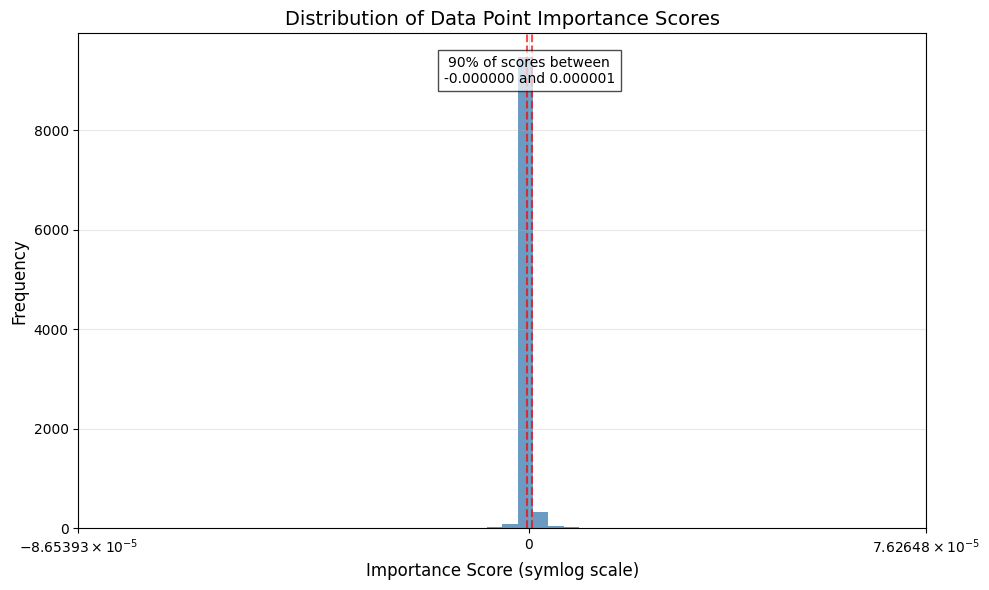

Top 20 most influential data points:
1. Index 6832: Importance score = 0.000069
2. Index 2156: Importance score = 0.000058
3. Index 4165: Importance score = 0.000027
4. Index 4513: Importance score = 0.000027
5. Index 9147: Importance score = 0.000024
6. Index 5042: Importance score = 0.000024
7. Index 6605: Importance score = 0.000022
8. Index 8639: Importance score = 0.000017
9. Index 9953: Importance score = 0.000016
10. Index 3094: Importance score = 0.000015
11. Index 3675: Importance score = 0.000015
12. Index 6716: Importance score = 0.000015
13. Index 3861: Importance score = 0.000015
14. Index 3004: Importance score = 0.000014
15. Index 3250: Importance score = 0.000012
16. Index 7415: Importance score = 0.000012
17. Index 7751: Importance score = 0.000011
18. Index 1662: Importance score = 0.000011
19. Index 4892: Importance score = 0.000010
20. Index 5539: Importance score = 0.000010


In [7]:
from matplotlib import pyplot as plt
import numpy as np

problem_idx = np.argsort(importances)[::-1]  # Sort in descending order

# Let's visualize the distribution of importance scores with improved visualization
plt.figure(figsize=(10, 6))

# Create histogram with all data points
plt.hist(importances, bins=50, color='steelblue', alpha=0.8)
plt.title('Distribution of Data Point Importance Scores', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

# Find and mark the range where most data points fall
percentile_95 = np.percentile(importances, 95)
percentile_5 = np.percentile(importances, 5)
plt.axvline(x=percentile_5, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=percentile_95, color='red', linestyle='--', alpha=0.7)

# Add text annotation about the central range
plt.text((percentile_5 + percentile_95)/2, plt.ylim()[1]*0.9,
         f'90% of scores between\n{percentile_5:.6f} and {percentile_95:.6f}',
         horizontalalignment='center', bbox=dict(facecolor='white', alpha=0.7))

# Format the axis to be more readable - consider logarithmic scale if highly skewed
if np.max(importances) / np.median(abs(importances)) > 100:
    plt.xscale('symlog')  # Symmetric log scale handles both positive and negative values
    plt.xlabel('Importance Score (symlog scale)', fontsize=12)

plt.tight_layout()
plt.show()

# Print the most influential data points (potential problems)
print("Top 20 most influential data points:")
for i, idx in enumerate(problem_idx[:20]):
    print(f"{i+1}. Index {idx}: Importance score = {importances[idx]:.6f}")

In [9]:
# Create a DataFrame for better visualization of problematic data points
import pandas as pd
top_problematic = pd.DataFrame({
    'Index': problem_idx[:20],
    'Importance': [importances[idx] for idx in problem_idx[:20]],
    'Dirty_Label': [y_train_dirty[idx] for idx in problem_idx[:20]],
    'True_Label': [y_train[idx] for idx in problem_idx[:20]],
    'Is_Mislabeled': [y_train_dirty[idx] != y_train[idx] for idx in problem_idx[:20]]
})
print("\nSummary of top problematic data points:")
top_problematic


Summary of top problematic data points:


,Index,Importance,Dirty_Label,True_Label,Is_Mislabeled
0,6832,0.000069,0,0,False
1,2156,0.000058,0,0,False
2,4165,0.000027,0,0,False
3,4513,0.000027,0,0,False
4,9147,0.000024,1,1,False
5,5042,0.000024,1,1,False
6,6605,0.000022,1,0,True
7,8639,0.000017,0,0,False
8,9953,0.000016,1,0,True
9,3094,0.000015,1,0,True


In [10]:
# Extract the corresponding rows from X_train_dirty
# If X_train_dirty is a DataFrame, use iloc for position-based indexing
if isinstance(X_train_dirty, pd.DataFrame):
    problematic_samples = X_train_dirty.iloc[top_problematic['Index']].copy()
else:
    # If it's a numpy array
    problematic_samples = pd.DataFrame(X_train_dirty[top_problematic['Index']])

print("Extracted problematic samples from X_train_dirty:")
problematic_samples

Extracted problematic samples from X_train_dirty:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,56,Private,345730,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States
1,54,Private,183668,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States
2,63,Private,149756,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,0,1740,40,United-States
3,52,Private,163051,12th,8,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,1628,40,United-States
4,31,Private,290964,Assoc-voc,11,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
5,42,Private,111483,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,50,United-States
6,41,Local-gov,137142,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States
7,50,Private,191062,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States
8,35,Private,191807,Assoc-voc,11,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States
9,28,Private,360527,Some-college,10,Never-married,Sales,Not-in-family,White,Male,0,0,45,United-States


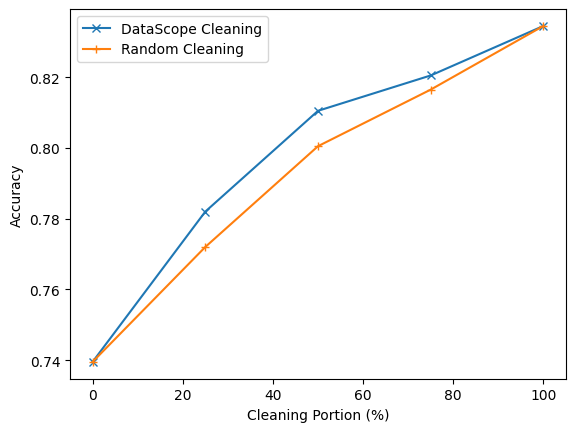

In [11]:
random_cleaning_acc = []
datascope_cleaning_acc = []

MAX_CLEAN_PERCENT = 100 + 1
STEP_PERCENT = 25

# clean with datascope
for cleaning_portion in range(0, MAX_CLEAN_PERCENT, STEP_PERCENT):

    target_idx = np.argsort(importances)[:int(cleaning_portion * N_TRAIN / 100)]
    X_train_repaired, y_train_repaired = np.copy(X_train_dirty), np.copy(y_train_dirty)
    y_train_repaired[target_idx] = y_train[target_idx]
    pipeline.fit(X_train_repaired, y_train_repaired)
    y_pred = pipeline.predict(X_test)
    accuracy_repaired = accuracy_score(y_test, y_pred)

    datascope_cleaning_acc.append(accuracy_repaired)

# clean with random
np.random.seed(65535)
random_importances = np.random.rand(len(importances))
for cleaning_portion in range(0, MAX_CLEAN_PERCENT, STEP_PERCENT):

    target_idx = np.argsort(random_importances)[:int(cleaning_portion * N_TRAIN / 100)]
    X_train_repaired, y_train_repaired = np.copy(X_train_dirty), np.copy(y_train_dirty)
    y_train_repaired[target_idx] = y_train[target_idx]
    pipeline.fit(X_train_repaired, y_train_repaired)
    y_pred = pipeline.predict(X_test)
    accuracy_repaired = accuracy_score(y_test, y_pred)

    random_cleaning_acc.append(accuracy_repaired)

# Plot
import matplotlib.pyplot as plt
plt.plot(range(0, MAX_CLEAN_PERCENT, STEP_PERCENT), datascope_cleaning_acc, '-x', label="DataScope Cleaning")
plt.plot(range(0, MAX_CLEAN_PERCENT, STEP_PERCENT), random_cleaning_acc, '-+', label="Random Cleaning")
plt.xlabel("Cleaning Portion (%)")
plt.ylabel("Accuracy")
plt.legend()

In [12]:
print("Final Accuracy after DataShapley Cleaning:", datascope_cleaning_acc[-1])
print("Final Accuracy after Random Cleaning:", random_cleaning_acc[-1])

Final Accuracy after DataShapley Cleaning: 0.8345
Final Accuracy after Random Cleaning: 0.8345
